In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import yfinance as yf
from pygam import LinearGAM, s

sns.set_theme(style="whitegrid")

## Data Loading and Prep

In [2]:
riv_pm25 = pd.read_csv("data/rivian_normal_IL_US_pm25.csv")
riv_viirs = pd.read_csv("data/rivian_viirs_2yrs.csv")

In [3]:
riv_pm25

,date,pm25,o3
0,2025/10/1,39,54
1,2025/10/2,41,44
2,2025/10/3,40,44
3,2025/10/4,49,36
4,2025/10/5,28,31
...,...,...,...
3862,2015/3/27,,30
3863,2015/3/28,,33
3864,2015/3/29,,31
3865,2015/3/30,,36


In [4]:
riv_viirs

,Unnamed: 0,date,radiance
0,0,2023-01-01,35.655800
1,1,2023-01-04,96.967276
2,2,2023-01-09,128.798241
3,3,2023-01-10,98.447848
4,4,2023-01-17,71.943200
...,...,...,...
641,641,2025-09-23,80.485802
642,642,2025-09-24,70.656458
643,643,2025-09-25,66.737014
644,644,2025-09-26,114.540210


In [5]:
riv_pm25.columns = riv_pm25.columns.str.strip()
riv_pm25["date"] = pd.to_datetime(riv_pm25["date"], errors="coerce")
riv_pm25["pm25"] = pd.to_numeric(riv_pm25["pm25"], errors="coerce")
riv_pm25 = riv_pm25.dropna(subset=["date", "pm25"])

In [6]:
riv_pm25

,date,pm25,o3
0,2025-10-01,39.0,54
1,2025-10-02,41.0,44
2,2025-10-03,40.0,44
3,2025-10-04,49.0,36
4,2025-10-05,28.0,31
...,...,...,...
3188,2016-12-29,26.0,20
3189,2016-12-30,15.0,25
3190,2016-12-31,19.0,24
3191,2017-01-01,33.0,22


In [7]:
riv_viirs["date"] = pd.to_datetime(riv_viirs["date"], errors="coerce")
riv_viirs = riv_viirs.dropna(subset=["date", "radiance"])

riv_viirs

,Unnamed: 0,date,radiance
0,0,2023-01-01,35.655800
1,1,2023-01-04,96.967276
2,2,2023-01-09,128.798241
3,3,2023-01-10,98.447848
4,4,2023-01-17,71.943200
...,...,...,...
641,641,2025-09-23,80.485802
642,642,2025-09-24,70.656458
643,643,2025-09-25,66.737014
644,644,2025-09-26,114.540210


In [8]:
print("PM2.5 records:", len(riv_pm25), " | VIIRS records:", len(riv_viirs))

PM2.5 records: 3193  | VIIRS records: 646


In [9]:
rivn = yf.download("RIVN", start="2022-01-01", progress=False)

/tmp/ipykernel_49105/2581235847.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rivn = yf.download("RIVN", start="2022-01-01", progress=False)


In [10]:
rivn

Price,Close,High,Low,Open,Volume
Ticker,RIVN,RIVN,RIVN,RIVN,RIVN
Date,,,,,
2022-01-03,102.720001,106.550003,100.250000,106.139999,8346800
2022-01-04,101.389999,106.800003,99.014000,102.989998,12152200
2022-01-05,90.010002,99.214996,89.279999,98.320000,18645100
2022-01-06,87.330002,92.029999,75.129997,91.879997,39827100
2022-01-07,86.279999,89.269997,81.621002,87.019997,17515900
...,...,...,...,...,...
2025-10-17,13.030000,13.215000,12.870000,12.900000,24003800
2025-10-20,13.080000,13.150000,12.660000,12.800000,35626600


In [11]:
rivn.columns = rivn.columns.get_level_values(0)

rivn = rivn[["Close", "Volume"]].copy()

In [12]:
rivn.reset_index(inplace=True)
rivn.rename(
    columns={"Date": "date", "Close": "close", "Volume": "volume"}, inplace=True
)

# Convert types
rivn["date"] = pd.to_datetime(rivn["date"])
rivn["close"] = pd.to_numeric(rivn["close"], errors="coerce")
rivn["volume"] = pd.to_numeric(rivn["volume"], errors="coerce")

In [13]:
rivn

Price,date,close,volume
0,2022-01-03,102.720001,8346800
1,2022-01-04,101.389999,12152200
2,2022-01-05,90.010002,18645100
3,2022-01-06,87.330002,39827100
4,2022-01-07,86.279999,17515900
...,...,...,...
951,2025-10-17,13.030000,24003800
952,2025-10-20,13.080000,35626600
953,2025-10-21,13.200000,27959900
954,2025-10-22,12.920000,41791700


In [14]:
rivn["pct_close_chg"] = rivn["close"].pct_change() * 100

rivn["pct_close_chg"] = rivn["pct_close_chg"]

In [15]:
rivn.drop(columns=["volume"], inplace=True)

In [16]:
rivn

Price,date,close,pct_close_chg
0,2022-01-03,102.720001,NaN
1,2022-01-04,101.389999,-1.294784
2,2022-01-05,90.010002,-11.223984
3,2022-01-06,87.330002,-2.977447
4,2022-01-07,86.279999,-1.202339
...,...,...,...
951,2025-10-17,13.030000,0.929511
952,2025-10-20,13.080000,0.383731
953,2025-10-21,13.200000,0.917430
954,2025-10-22,12.920000,-2.121210


In [17]:
rivn_join = rivn.merge(riv_pm25, on="date", how="inner")
rivn_join.drop(columns=["o3"], inplace=True)

In [18]:
rivn_join

,date,close,pct_close_chg,pm25
0,2022-01-04,101.389999,-1.294784,46.0
1,2022-01-05,90.010002,-11.223984,41.0
2,2022-01-06,87.330002,-2.977447,42.0
3,2022-01-07,86.279999,-1.202339,22.0
4,2022-01-10,81.440002,-5.609639,33.0
...,...,...,...,...
942,2025-10-09,13.090000,-0.304646,14.0
943,2025-10-10,12.800000,-2.215431,21.0
944,2025-10-13,13.060000,2.031252,31.0
945,2025-10-14,13.120000,0.459414,44.0


Mean Close Price: 21.10
Mean % Close Change: -0.10


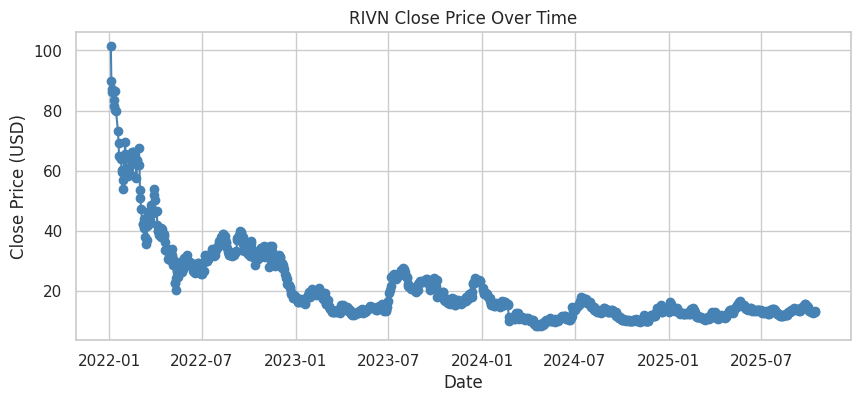

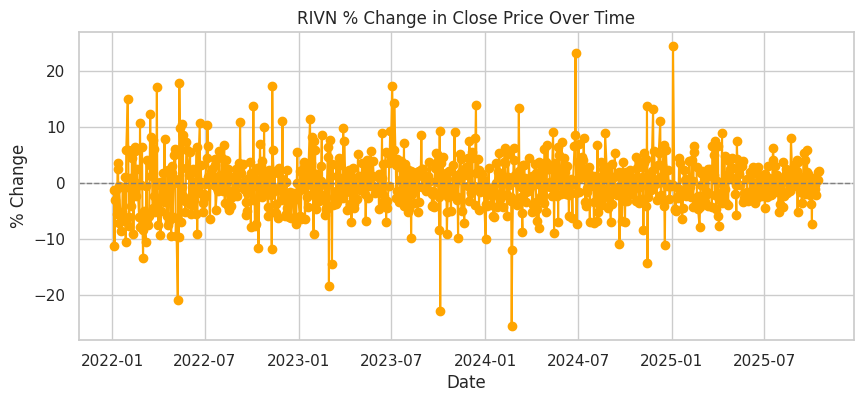

In [32]:
# --- Calculate means ---
mean_close = rivn_join["close"].mean()
mean_pct_change = rivn_join["pct_close_chg"].mean()

print(f"Mean Close Price: {mean_close:.2f}")
print(f"Mean % Close Change: {mean_pct_change:.2f}")

# --- Plot Close Price ---
plt.figure(figsize=(10, 4))
plt.plot(rivn_join["date"], rivn_join["close"], marker="o", color="steelblue")
plt.title("RIVN Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.grid(True)
plt.show()

# --- Plot % Change in Close ---
plt.figure(figsize=(10, 4))
plt.plot(rivn_join["date"], rivn_join["pct_close_chg"], marker="o", color="orange")
plt.title("RIVN % Change in Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("% Change")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.grid(True)
plt.show()

We will proceed with the objective of forecasting the % change due the staionarity principles.

## Modelling

### Feature Engineering

In [19]:
df = rivn_join.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

for c in ["close", "pct_close_chg", "pm25"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [20]:
win = 30
pm = df["pm25"]

# Rolling center & dispersion (use median + std; you can swap std for MAD to be extra robust)
center = pm.rolling(win, min_periods=win // 2).median()
disp = pm.rolling(win, min_periods=win // 2).std()

df["pm25_level_z"] = (pm - center) / disp

In [21]:
# Robust anomaly via MAD (optional, uncomment if you prefer)
# mad = (pm - center).abs().rolling(win, min_periods=win//2).median()
# df['pm25_level_anom'] = (pm - center) / (1.4826 * mad)

# Log transforms (log1p handles zeros safely)
df["pm25_log"] = np.log1p(df["pm25"])
df["pm25_log_diff"] = df["pm25_log"].diff()

In [22]:
# 3) Target prep
# Your pct_close_chg is in percent; standardize to help comparability (optional)
y = (df["pct_close_chg"] - df["pct_close_chg"].mean()) / df["pct_close_chg"].std()

# Candidate features to sweep lags over
candidates = [
    "pm25_level_z",
    "pm25_log_diff",
    "pm25_log",
]  # add 'pm25_level_anom' if you enabled it
lags = range(0, 61)

rows = []
for feat in candidates:
    x0 = df[feat]
    for k in lags:
        x = x0.shift(k)
        m = pd.concat([y, x], axis=1).dropna()
        if len(m) < 120:  # require reasonable overlap
            continue
        # Pearson
        r = m.iloc[:, 0].corr(m.iloc[:, 1])
        # Mutual information (nonlinear)
        mi = mutual_info_regression(
            m.iloc[:, 1].values.reshape(-1, 1), m.iloc[:, 0].values, random_state=0
        )[0]
        rows.append(
            {"feature": feat, "lag_days": k, "n": len(m), "pearson_r": r, "mi": mi}
        )

In [23]:
results = pd.DataFrame(rows)

In [24]:
results

,feature,lag_days,n,pearson_r,mi
0,pm25_level_z,0,933,-0.029621,0.000000
1,pm25_level_z,1,932,-0.031439,0.005844
2,pm25_level_z,2,931,-0.019908,0.000000
3,pm25_level_z,3,930,0.063064,0.003408
4,pm25_level_z,4,929,0.078570,0.007376
...,...,...,...,...,...
178,pm25_log,56,891,0.002790,0.042127
179,pm25_log,57,890,-0.025084,0.000000
180,pm25_log,58,889,0.032392,0.000000
181,pm25_log,59,888,0.014007,0.000000


In [25]:
top_corr = (
    results.assign(abs_r=lambda d: d["pearson_r"].abs())
    .sort_values(["abs_r", "n"], ascending=[False, False])
    .head(10)
)

top_mi = results.sort_values(["mi", "n"], ascending=[False, False]).head(10)

In [26]:
print("Top 10 by |Pearson r|")
display(top_corr)

Top 10 by |Pearson r|


,feature,lag_days,n,pearson_r,mi,abs_r
5,pm25_level_z,5,928,0.081608,0.002087,0.081608
163,pm25_log,41,906,-0.078903,0.039818,0.078903
4,pm25_level_z,4,929,0.078570,0.007376,0.078570
111,pm25_log_diff,50,896,0.073025,0.000000,0.073025
109,pm25_log_diff,48,898,-0.072426,0.015495,0.072426
41,pm25_level_z,41,892,-0.070329,0.000000,0.070329
63,pm25_log_diff,2,944,-0.070229,0.000000,0.070229
9,pm25_level_z,9,924,0.065776,0.002322,0.065776
112,pm25_log_diff,51,895,-0.065337,0.000000,0.065337
127,pm25_log,5,942,0.065108,0.000000,0.065108


In [27]:
print("\nTop 10 by Mutual Information")
display(top_mi)


Top 10 by Mutual Information


,feature,lag_days,n,pearson_r,mi
88,pm25_log_diff,27,919,-0.050304,0.061138
79,pm25_log_diff,18,928,-0.064998,0.052391
95,pm25_log_diff,34,912,-0.030712,0.047889
94,pm25_log_diff,33,913,0.000401,0.047340
36,pm25_level_z,36,897,-0.027830,0.046954
6,pm25_level_z,6,927,0.063257,0.045625
182,pm25_log,60,887,0.010328,0.044522
44,pm25_level_z,44,889,-0.031695,0.044275
115,pm25_log_diff,54,892,0.024558,0.044114
26,pm25_level_z,26,907,0.016346,0.044093


### Linear Regression

In [28]:
# 5) Fit a quick OLS on the single best MI spec
best = top_mi.iloc[0]
feat, k = best["feature"], int(best["lag_days"])
x = df[feat].shift(k)
m = pd.concat([y, x], axis=1).dropna()
X = sm.add_constant(m.iloc[:, 1].values)  # feature
ols = sm.OLS(m.iloc[:, 0].values, X).fit()
print(f"\nOLS on best MI spec: y = standardized pct_close_chg, X = {feat} lag {k} days")
print(ols.summary())


OLS on best MI spec: y = standardized pct_close_chg, X = pm25_log_diff lag 27 days
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.326
Date:                Thu, 23 Oct 2025   Prob (F-statistic):              0.128
Time:                        17:35:45   Log-Likelihood:                -1292.5
No. Observations:                 919   AIC:                             2589.
Df Residuals:                     917   BIC:                             2599.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

We basically get random results, indicating no effectiveness of linear modelling.

### GAM

In [29]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, LogisticGAM, s
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data prep ---
df = rivn_join.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Ensure numeric
for c in ["close", "pct_close_chg", "pm25"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Create target (next-day direction)
df["y_up_next"] = (df["pct_close_chg"].shift(-1) > 0).astype(int)

# PM2.5 features (and lag if needed)
df["pm25_log"] = np.log1p(df["pm25"])
df["pm25_level_z"] = (df["pm25"] - df["pm25"].rolling(30).mean()) / df["pm25"].rolling(
    30
).std()

# Drop missing values
df = df.dropna(subset=["pm25_level_z", "pct_close_chg", "y_up_next"])

# Train-test split by time (last 20% as test)
split_idx = int(len(df) * 0.8)
train, test = df.iloc[:split_idx], df.iloc[split_idx:]

# Define features and target
X_train = train[["pm25_level_z"]]
X_test = test[["pm25_level_z"]]
y_train_reg = train["pct_close_chg"]
y_test_reg = test["pct_close_chg"]
y_train_cls = train["y_up_next"]
y_test_cls = test["y_up_next"]

By subtracting the rolling mean and dividing by the rolling standard deviation, you get a standardized value (z-score) for each day:

$$
z = \frac{\text{Today's PM2.5} - \text{Average PM2.5 (last 30 days)}}{\text{Std Dev PM2.5 (last 30 days)}}
$$


This tells you **how unusual today's pollution level is compared to recent history**:

- **Positive values:** Higher than usual pollution for that period.
- **Negative values:** Lower than usual pollution.
- **Values near zero:** Typical, not unusual.

In short, the `"pm25_level_z` feature quantifies PM2.5 “anomaly” relative to a moving 30-day baseline, making it easy to spot environmental spikes or drops.


In [30]:
# Fit GAM for binary direction
gam_cls = LogisticGAM(s(0, n_splines=15)).fit(X_train, y_train_cls)

# Predictions and accuracy
pred_probs = gam_cls.predict_proba(X_test)
pred_dir = (pred_probs >= 0.5).astype(int)

acc = accuracy_score(y_test_cls, pred_dir)
print(f"Directional accuracy (test): {acc:.3f}")

print("\nClassification report:")
print(classification_report(y_test_cls, pred_dir, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test_cls, pred_dir))

Directional accuracy (test): 0.516

Classification report:
              precision    recall  f1-score   support

           0      0.509     0.935     0.659        92
           1      0.600     0.098     0.168        92

    accuracy                          0.516       184
   macro avg      0.554     0.516     0.414       184
weighted avg      0.554     0.516     0.414       184

Confusion matrix:
[[86  6]
 [83  9]]


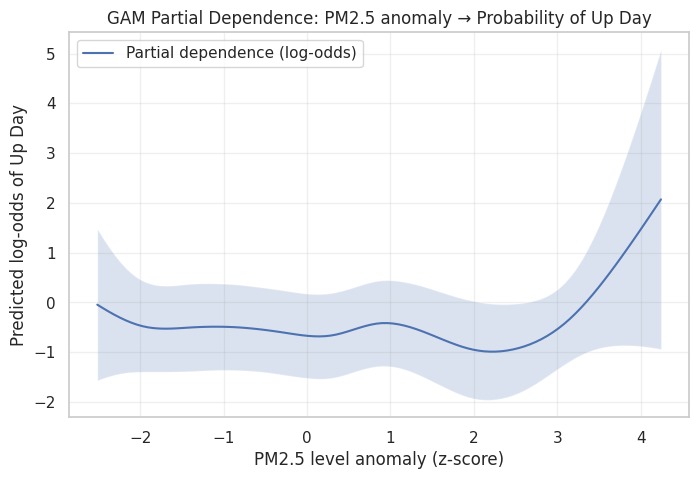

In [31]:
# Visualize nonlinear link
XX = gam_cls.generate_X_grid(term=0)
pdep, confi = gam_cls.partial_dependence(term=0, X=XX, width=0.95)

plt.figure(figsize=(8, 5))
plt.plot(XX[:, 0], pdep, label="Partial dependence (log-odds)")
plt.fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.2)
plt.title("GAM Partial Dependence: PM2.5 anomaly → Probability of Up Day")
plt.xlabel("PM2.5 level anomaly (z-score)")
plt.ylabel("Predicted log-odds of Up Day")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The plot demonstrates that extremely high PM2.5 pollution anomalies, shown as large positive z-scores, may be associated with a sharply increased likelihood that Rivian’s stock goes up the following day. These rare spikes in pollution can act as early indicators of operational surprises or news events, offering potential alpha opportunities by highlighting signals not yet incorporated into market pricing.

For pollution levels closer to average, around zero on the z-score scale, the model does not indicate any strong or actionable relationship with stock price direction. In this typical range, PM2.5 data does not seem to provide a useful edge for systematic investing decisions.

At the extremes where opportunities appear, the model’s confidence intervals are much wider, indicating greater uncertainty. Any strategy that uses these alternative data signals should incorporate careful risk management and robust validation to capture inefficiencies while minimizing exposure to estimation error and noise.

## Conclusion

Overall, this analysis highlights the value of PM2.5 pollution data as a differentiated alternative source for quantitative investment strategies. By revealing connections between real-world environmental anomalies and short-term price movements, our products can help asset managers develop unique non-consensus signals, diversify their factor exposure, and potentially outperform more conventional approaches that rely solely on traditional financial indicators.